In [ ]:

# IMPORTS: Logistic Regression 

# Core Data Manipulation
import pandas as pd
import os #dont import if you are not using kaggle cell

# Model Selection, Scaling, & Evaluation
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, recall_score, roc_auc_score, confusion_matrix, classification_report

# Imbalanced Learning & Leak-Free Pipeline
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline  # Safe resampling pipeline

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Suppress potential warnings for clean notebook execution
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# ignore this cell if you are not using Kaggle notebook. 
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))



/kaggle/input/datasets/organizations/mlg-ulb/creditcardfraud/creditcard.csv


# Phase 1: Data Ingestion & Stratified Splitting

In [ ]:

# 1. Load the Credit Card Fraud Detection Dataset
#Change path according to your Enviroment
df = pd.read_csv('File_Path_Here')

# 2. Extract Features (X) and Target Label (y)
# 'Class' is our target where 0 = Legitimate, 1 = Fraudulent
X = df.drop(columns=['Class'])
y = df['Class']

# 3. Verify Extreme Class Imbalance Ratio Before Splitting
print("--- Baseline Class Distribution ---")
total_pool = len(df)
legit_count = (y == 0).sum()
fraud_count = (y == 1).sum()

print(f"Total Transaction Pool: {total_pool:,}")
print(f"Legitimate Volume: {legit_count:,} ({legit_count/total_pool*100:.2f}%)")
print(f"Fraudulent Volume: {fraud_count:,} ({fraud_count/total_pool*100:.2f}%)")
print("-" * 35)

# 4. Execute the Stratified Train/Test Split (80/20)
# stratify=y guarantees the 0.17% fraud ratio is perfectly preserved in both subsets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.20, 
    random_state=42, 
    stratify=y
)

print("\n--- Split Verification ---")
print(f"X_train Shape: {X_train.shape} | Fraud Ratio: {(y_train == 1).sum()/len(y_train)*100:.3f}%")
print(f"X_test Shape:  {X_test.shape}  | Fraud Ratio: {(y_test == 1).sum()/len(y_test)*100:.3f}%")
print("\n[LEAK-FREE GUARDRAIL ACTIVE]: Raw test structures successfully isolated.")

--- Baseline Class Distribution ---
Total Transaction Pool: 284,807
Legitimate Volume: 284,315 (99.83%)
Fraudulent Volume: 492 (0.17%)
-----------------------------------

--- Split Verification ---
X_train Shape: (227845, 30) | Fraud Ratio: 0.173%
X_test Shape:  (56962, 30)  | Fraud Ratio: 0.172%

[LEAK-FREE GUARDRAIL ACTIVE]: Raw test structures successfully isolated.


# PHASE 2: LINEAR PIPELINE ARCHITECTURE (LOGISTIC REGRESSION)

In [13]:
# Constructing the strict linear sequence using imblearn's pipeline
lr_pipeline = ImbPipeline(steps=[
    ('scaler', StandardScaler()),                 # 1. Feature Scaling (Mandatory for LR)
    ('smote', SMOTE(random_state=42)),            # 2. Resampling Chamber (Synthetic balancing)
    ('classifier', LogisticRegression(max_iter=1000, random_state=42)) # 3. Linear Estimator
])

print("--- Notebook 1 Pipeline Blueprint ---")
print(lr_pipeline)
print("\n[SECURITY CHECK]: StandardScaler safely isolated inside the cross-validation framework.")

--- Notebook 1 Pipeline Blueprint ---
Pipeline(steps=[('scaler', StandardScaler()), ('smote', SMOTE(random_state=42)),
                ('classifier',
                 LogisticRegression(max_iter=1000, random_state=42))])

[SECURITY CHECK]: StandardScaler safely isolated inside the cross-validation framework.


# PHASE 3: HOLISTIC HYPERPARAMETER TUNING (LOGISTIC REGRESSION)

In [14]:

# 1. Define the parameter grid using the step prefix 'smote__' and 'classifier__'
param_grid_lr = {
    'smote__k_neighbors': [3, 5, 7],               # Tuning the neighborhood framework
    'classifier__C': [0.01, 0.1, 1.0, 10.0]        # Regularization strength
}

# 2. Instantiate GridSearchCV with 5-Fold Stratified Cross-Validation
# We optimize for 'roc_auc' to protect against the "accuracy illusion"
grid_lr = GridSearchCV(
    estimator=lr_pipeline,
    param_grid=param_grid_lr,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

# 3. Trigger the safe training loop
print("--- Launching Logistic Regression Grid Search (5-Fold CV) ---")
grid_lr.fit(X_train, y_train)

print("\n--- Tuning Complete ---")
print(f"Best Parameters Found: {grid_lr.best_params_}")
print(f"Best Cross-Validated ROC-AUC: {grid_lr.best_score_:.4f}")

--- Launching Logistic Regression Grid Search (5-Fold CV) ---
Fitting 5 folds for each of 12 candidates, totalling 60 fits

--- Tuning Complete ---
Best Parameters Found: {'classifier__C': 0.01, 'smote__k_neighbors': 3}
Best Cross-Validated ROC-AUC: 0.9804


# PHASE 4: STRICT EVALUATION FRAMEWORK (LOGISTIC REGRESSION)

       LOGISTIC REGRESSION FINAL EVALUATION       
Strict Precision Score : 0.0591
Strict Recall Score    : 0.9184
Final ROC-AUC Benchmark: 0.9719 (Target: 0.85+)
--------------------------------------------------

Classification Report:
                precision    recall  f1-score   support

Legitimate (0)       1.00      0.97      0.99     56864
Fraudulent (1)       0.06      0.92      0.11        98

      accuracy                           0.97     56962
     macro avg       0.53      0.95      0.55     56962
  weighted avg       1.00      0.97      0.99     56962



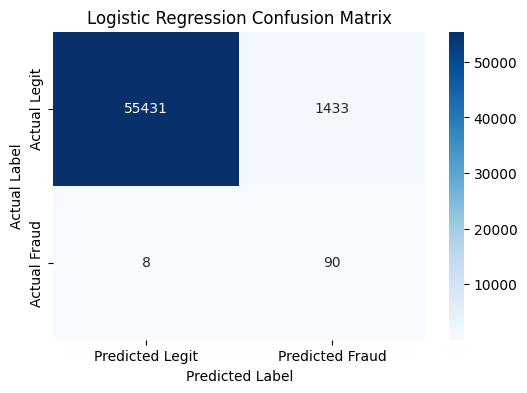

In [15]:
# 1. Extract the optimized leak-free model from GridSearchCV
best_lr_model = grid_lr.best_estimator_

# 2. Predict on the untouched, raw test data
y_pred_lr = best_lr_model.predict(X_test)
y_pred_proba_lr = best_lr_model.predict_proba(X_test)[:, 1] # Probability scores for ROC-AUC

# 3. Calculate metrics under strict financial guardrails
precision_lr = precision_score(y_test, y_pred_lr)
recall_lr = recall_score(y_test, y_pred_lr)
roc_auc_lr = roc_auc_score(y_test, y_pred_proba_lr)

print("==================================================")
print("       LOGISTIC REGRESSION FINAL EVALUATION       ")
print("==================================================")
print(f"Strict Precision Score : {precision_lr:.4f}")
print(f"Strict Recall Score    : {recall_lr:.4f}")
print(f"Final ROC-AUC Benchmark: {roc_auc_lr:.4f} (Target: 0.85+)")
print("-" * 50)

# 4. Print Complete Classification Breakdown
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr, target_names=['Legitimate (0)', 'Fraudulent (1)']))

# 5. Plot the Confusion Matrix Graph
plt.figure(figsize=(6, 4))
cm_lr = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Predicted Legit', 'Predicted Fraud'],
            yticklabels=['Actual Legit', 'Actual Fraud'])
plt.title("Logistic Regression Confusion Matrix")
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()